In [15]:
import pandas as pd
from pyaxis import pyaxis
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle


In [16]:
# Open data files
# YES NO RESULTS
votations_yes_no =r'C:\Users\flora\Desktop\HSLU\Semester 3\Data Visualization\Project\px-x-1703010000_102.px'
px_votations_number = pyaxis.parse(votations_yes_no, encoding='ISO-8859-2')

# Convert data into dataframes
votations_yes_no = px_votations_number['DATA']

# POPULAR VOTATIONS
votations_results = r'C:\Users\flora\Desktop\HSLU\Semester 3\Data Visualization\Project\px-x-1703030000_100.px'
px_votations_results = pyaxis.parse(votations_results, encoding='ISO-8859-2')

# Convert data into dataframes
votations_results = px_votations_results['DATA']
votations_results_meta = px_votations_results['METADATA']
votations_results

,Kanton,Datum und Vorlage,Ergebnis,DATA
0,Schweiz,2023-06-18 Änderung des Bundesgesetzes über di...,Stimmberechtigte,5567120
1,Schweiz,2023-06-18 Änderung des Bundesgesetzes über di...,Abgegebene Stimmen,2365154
2,Schweiz,2023-06-18 Änderung des Bundesgesetzes über di...,Beteiligung in %,42.4843366
3,Schweiz,2023-06-18 Änderung des Bundesgesetzes über di...,Gültige Stimmzettel,2321994
4,Schweiz,2023-06-18 Änderung des Bundesgesetzes über di...,Ja,1438216
...,...,...,...,...
128893,Jura,1866-01-14 Festsetzung von Mass und Gewicht,Beteiligung in %,"""..."""
128894,Jura,1866-01-14 Festsetzung von Mass und Gewicht,Gültige Stimmzettel,"""..."""
128895,Jura,1866-01-14 Festsetzung von Mass und Gewicht,Ja,"""..."""
128896,Jura,1866-01-14 Festsetzung von Mass und Gewicht,Nein,"""..."""


In [17]:
def convert_column_numeric(dataframe,*columns):
    """Convert the column content into numeric."""
    for name in columns:
        dataframe[name] = pd.to_numeric(dataframe[name], errors='coerce')
    return dataframe

In [18]:
# Add date column
votations_results[['Datum', 'Vorlage']] = votations_results['Datum und Vorlage'].str.split(' ', n=1, expand=True)
votations_results.drop('Datum und Vorlage', axis=1, inplace=True)

# Add  year, month and day columns
votations_results[['Jahr', 'Monat', 'Tag']] = votations_results['Datum'].str.split('-', n=2, expand=True)

In [19]:
# Select Switzerland and participation % only
votations_percentage = votations_results.loc[(votations_results.Kanton == 'Schweiz') & (votations_results.Ergebnis == 'Beteiligung in %')]
votations_percentage = convert_column_numeric(votations_percentage, 'DATA', 'Jahr', 'Monat', 'Tag')
votations_percentage = votations_percentage.drop(columns=['Ergebnis'], axis=1)
votations_percentage = votations_percentage.rename(columns={"DATA": "Beteiligung"})
votations_percentage

C:\Users\flora\AppData\Local\Temp\ipykernel_26412\39196558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[name] = pd.to_numeric(dataframe[name], errors='coerce')


,Kanton,Beteiligung,Datum,Vorlage,Jahr,Monat,Tag
2,Schweiz,42.484337,2023-06-18,Änderung des Bundesgesetzes über die gesetzlic...,2023,6,18
9,Schweiz,42.537901,2023-06-18,"Bundesgesetz über die Ziele im Klimaschutz, di...",2023,6,18
16,Schweiz,42.367023,2023-06-18,Bundesbeschluss über eine besondere Besteuerun...,2023,6,18
23,Schweiz,51.706867,2022-09-25,Änderung des Bundesgesetzes über die Verrechnu...,2022,9,25
30,Schweiz,52.185342,2022-09-25,Änderung des Bundesgesetzes über die Alters- u...,2022,9,25
...,...,...,...,...,...,...,...
4741,Schweiz,NaN,1866-01-14,Stimmrecht der Niedergelassenen in kantonalen ...,1866,1,14
4748,Schweiz,NaN,1866-01-14,Besteuerung und zivilrechtliche Verhältnisse d...,1866,1,14
4755,Schweiz,NaN,1866-01-14,Stimmrecht der Niedergelassenen in Gemeindeang...,1866,1,14
4762,Schweiz,NaN,1866-01-14,Gleichstellung der Juden und Naturalisierten m...,1866,1,14


### Year range

In [20]:
# Select years range
years_range_low = 1880
years_range_high = 2024
participation_to_plot = votations_percentage.loc[(votations_percentage.Jahr >= years_range_low) &
                                                 (votations_percentage.Jahr < years_range_high)]
participation_to_plot

,Kanton,Beteiligung,Datum,Vorlage,Jahr,Monat,Tag
2,Schweiz,42.484337,2023-06-18,Änderung des Bundesgesetzes über die gesetzlic...,2023,6,18
9,Schweiz,42.537901,2023-06-18,"Bundesgesetz über die Ziele im Klimaschutz, di...",2023,6,18
16,Schweiz,42.367023,2023-06-18,Bundesbeschluss über eine besondere Besteuerun...,2023,6,18
23,Schweiz,51.706867,2022-09-25,Änderung des Bundesgesetzes über die Verrechnu...,2022,9,25
30,Schweiz,52.185342,2022-09-25,Änderung des Bundesgesetzes über die Alters- u...,2022,9,25
...,...,...,...,...,...,...,...
4601,Schweiz,57.248711,1884-05-11,Bundesgesetz betreffend die Organisation des e...,1884,5,11
4608,Schweiz,NaN,1882-11-26,Bundesbeschluss betreffend die Vollziehung des...,1882,11,26
4615,Schweiz,NaN,1882-07-30,Bundesgesez betreffend Massnahmen gegen gemein...,1882,7,30
4622,Schweiz,NaN,1882-07-30,Bundesbeschluss betreffend den Erfindungsschutz,1882,7,30


In [21]:
foreigners = participation_to_plot.loc[participation_to_plot.Vorlage.str.contains('Ausländ')]
atom = participation_to_plot.loc[participation_to_plot.Vorlage.str.contains('Atom')]
military = participation_to_plot.loc[participation_to_plot.Vorlage.str.contains('Militär')]
covid = participation_to_plot.loc[participation_to_plot.Vorlage.str.contains('Covid')]
#insurance = participation_to_plot.loc[participation_to_plot.Vorlage.str.contains('Versicherung')
# |participation_to_plot.Vorlage.str.contains('versicher')]

## Yes/No dataframe

In [22]:
# Simplify naming of index columns
votations_yes_no = votations_yes_no.rename(columns={'Kanton': 'Kanton', 'Periode': 'Years', 'Abstimmungsvorlage (Typ)':
    'Type', 'Abstimmungsvorlage (angenommen / verworfen)': 'Results', 'DATA': 'Data'})

# Split year from labels "Periode:" and "Jahr"
votations_yes_no[['Label', "Year"]] = votations_yes_no['Years'].str.split(': ', n=1, expand=True)
votations_yes_no.drop('Years', axis=1, inplace=True)

labels_to_delete = ['Periode', 'Jahrzehnt']
votations_yes_no = votations_yes_no[~votations_yes_no['Label'].str.startswith(tuple(labels_to_delete))]

votations_yes_no.drop('Label', axis=1, inplace=True)

# Convert years to integer
votations_yes_no['Data'] = pd.to_numeric(votations_yes_no['Data'], errors='coerce') #.astype(int)
votations_yes_no['Year'] = pd.to_numeric(votations_yes_no['Year'], errors='coerce')#.astype(int)

types_list = [item for item in votations_yes_no.Type.unique()]

def total_votation_per_type(type):
    """This function takes a valid type of the votations_yes_no dataframe as argument.
    Returns the dataframe with total number votations per year, for this type for Switzerland."""
    dataframe = votations_yes_no.loc[(votations_yes_no['Results'] == 'Total') & (votations_yes_no['Kanton'] ==
                                                                                 'Schweiz') & (votations_yes_no['Type'] == type)]
    return dataframe

In [23]:
# Create relative values
yes_no_to_plot = total_votation_per_type(types_list[5]) #types_list => types of votations
yes_no_to_plot = yes_no_to_plot.loc[(yes_no_to_plot.Year > years_range_low) & ( yes_no_to_plot.Year <
                                                                                years_range_high)]

# Add column with relative number of votations/year (%)
yes_no_to_plot['Data_relative'] = yes_no_to_plot.loc[:, 'Data']
yes_no_to_plot.Data_relative = yes_no_to_plot.Data_relative / 16 * 100

# Tools to plot

In [24]:
graph_colors = ['#1DA5E1', '#226B22', '#F23A29', '#533CA6', '#73175A'] # yellow: '#F2A007'
topics_list = [foreigners, military, atom, covid] # Dataframes
topics_titles = ['Foreigners', 'Military', 'Atom', 'Covid']


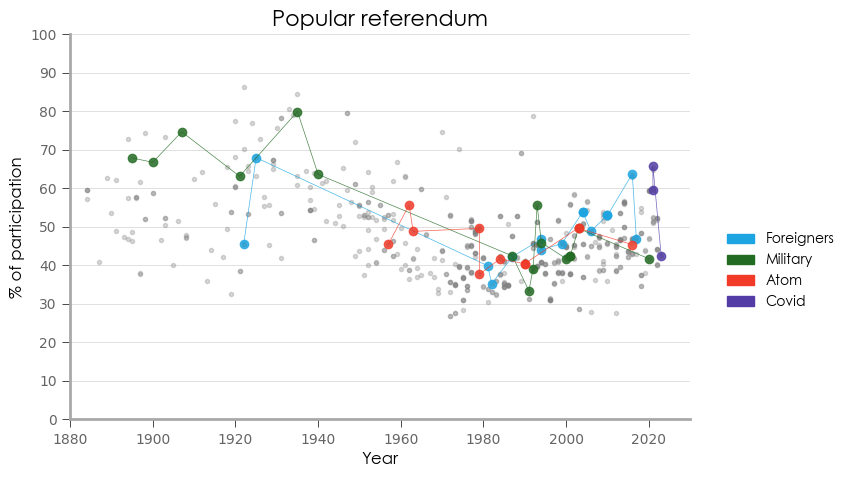

In [29]:
fig, ax = plt.subplots(figsize=(8,5))
ax.set_title('Popular referendum', loc='center', fontdict={'fontname': 'Century Gothic', 'size': 16})

# Data to plot
ax.scatter(participation_to_plot.Jahr, participation_to_plot.Beteiligung, marker='.', color='grey', alpha= 0.3,
           zorder=99)

ax.scatter(foreigners.Jahr, foreigners.Beteiligung, color=graph_colors[0], alpha= 0.8, zorder=99)
# OPTION FALLS INTERACTIVE MÖGLICH
ax.plot(foreigners.Jahr, foreigners.Beteiligung, color=graph_colors[0], alpha= 0.8, linewidth=0.5, zorder=99)
ax.scatter(military.Jahr, military.Beteiligung, color=graph_colors[1], alpha= 0.8, zorder=99)
# OPTION FALLS INTERACTIVE MÖGLICH
ax.plot(military.Jahr, military.Beteiligung, color=graph_colors[1], alpha= 0.8, linewidth=0.5, zorder=99)

ax.scatter(atom.Jahr, atom.Beteiligung, color=graph_colors[2], alpha= 0.8, zorder=99)
# OPTION FALLS INTERACTIVE MÖGLICH
ax.plot(atom.Jahr, atom.Beteiligung, color=graph_colors[2], alpha= 0.8, linewidth=0.5, zorder=99)

ax.scatter(covid.Jahr, covid.Beteiligung, color=graph_colors[3], alpha= 0.8, zorder=99)
# OPTION FALLS INTERACTIVE MÖGLICH
ax.plot(covid.Jahr, covid.Beteiligung, color=graph_colors[3], alpha= 0.8, linewidth=0.5, zorder=99)
ax.tick_params(axis='x', labelsize=10, labelcolor='#646464', direction='out', length=6, width=0.5)
ax.tick_params(axis='y', labelsize=10, labelcolor='#646464', direction='out', length=6, width=0.5)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_color('darkgrey')
ax.spines['left'].set_color('darkgrey')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set grid style
ax.grid(True, which='major', axis='y', color='lightgrey', linestyle='-', linewidth=0.5)

# Axis characteristics
ax.set_ylim(bottom=0, top=100)
ax.set_xlim(left=1880, right=2030)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
xlabel = ax.set_xlabel("Year", loc='center')
ylabel = ax.set_ylabel("% of participation")
xlabel.set_fontname('Century Gothic')
xlabel.set_size(12)

ylabel.set_fontname('Century Gothic')
ylabel.set_size(12)
ax.set_yticks(ticks=(0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100))

foreigners_patch = mpatches.Patch(color=graph_colors[0], label='Foreigners')
military_patch = mpatches.Patch(color=graph_colors[1], label='Military')
atom_patch = mpatches.Patch(color=graph_colors[2], label='Atom')
covid_patch = mpatches.Patch(color=graph_colors[3], label='Covid')

ax.legend(handles=[foreigners_patch, military_patch, atom_patch, covid_patch], loc='upper left', bbox_to_anchor=(1.05, 0.5), borderaxespad=0., frameon=False, prop={'family': 'Century Gothic', 'size': 10})



# Could also be displayed with the size of the circles ??

In [26]:
# Mean participation per year
participation_mean_to_plot = participation_to_plot.pivot_table('Beteiligung', 'Jahr', aggfunc="mean")

In [27]:
participation_mean_to_plot= participation_mean_to_plot.reset_index()
participation_mean_to_plot

,Jahr,Beteiligung
0,1884,58.937071
1,1887,40.835859
2,1889,62.737192
3,1890,53.560421
4,1891,55.544656
...,...,...
122,2019,41.846593
123,2020,52.687405
124,2021,57.909791
125,2022,45.928938


# Does not work
full_years = list(range(years_range_low, years_range_high))
missing_years = set(full_years) - set(participation_mean_to_plot.Jahr)

print(missing_years)

for year in missing_years:
    new_row = pd.DataFrame([0], 'Jahr'== year, 'Beteiligung'== 0)
    participation_mean_to_plot.append(new_row)
participation_mean_to_plot.sort_index(inplace=True)

participation_mean_to_plot

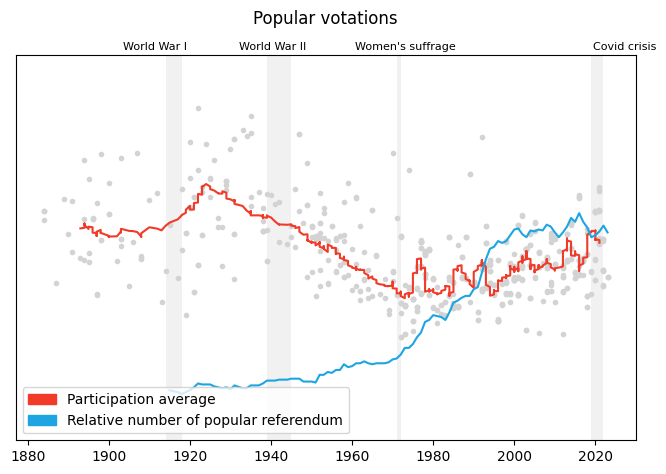

In [28]:
f, ax = plt.subplots(figsize=(8,5))

t = ax.set_title('Popular votations', loc='center', y=(1.06))
# Grid
ax.grid(axis="y", color="#D5D5D5", linestyle="-", linewidth=0.8)
# Area for annotations
ax.axvspan(1914, 1918, facecolor='lightgrey', alpha=0.3)
ax.axvspan(1939, 1945, facecolor='lightgrey', alpha=0.3)
ax.axvspan(1971, 1972, facecolor='lightgrey', alpha=0.3)
ax.axvspan(2019, 2022, facecolor='lightgrey', alpha=0.3)

# Variables annotations
y = -0.8
fs = 8
annotation_WWI = ax.annotate(xy=(-0.9,y), text="World War I", xycoords=t, ha='left', va='top', fontsize=fs)
annotation_WWII = ax.annotate(xy=(-0.10,y), text="World War II", xycoords=t, ha='left', va='top', fontsize=fs)
annotation_women = ax.annotate(xy=(0.70,y), text="Women's suffrage", xycoords=t, ha='left', va='top', fontsize=fs)
annotation_covid = ax.annotate(xy=(2.35,y), text="Covid crisis", xycoords=t, ha='left', va='top', fontsize=fs)

# Axis characteristics
ax.set_ylim(bottom=0, top=100)
ax.get_yaxis().set_visible(False)

yes_no_to_plot = yes_no_to_plot.sort_values('Year')

scatter = ax.scatter(participation_to_plot.Jahr, participation_to_plot.Beteiligung, marker='.', color='lightgrey')
moving_average = participation_to_plot.Beteiligung.rolling(window=25).mean()
ax.plot(participation_to_plot.Jahr, moving_average, color=graph_colors[2])

#ax.scatter(yes_no_to_plot.Year, yes_no_to_plot.Data_relative, marker='.')
moving_average2 = yes_no_to_plot.Data_relative.rolling(window=25).mean()
ax.plot(yes_no_to_plot.Year, moving_average2, color=graph_colors[0])

#Legend
participation_patch = mpatches.Patch(color=graph_colors[2], label='Participation average')
number_votation = mpatches.Patch(color=graph_colors[0], label='Relative number of popular referendum')
ax.legend(handles=[participation_patch, number_votation], loc='lower left')


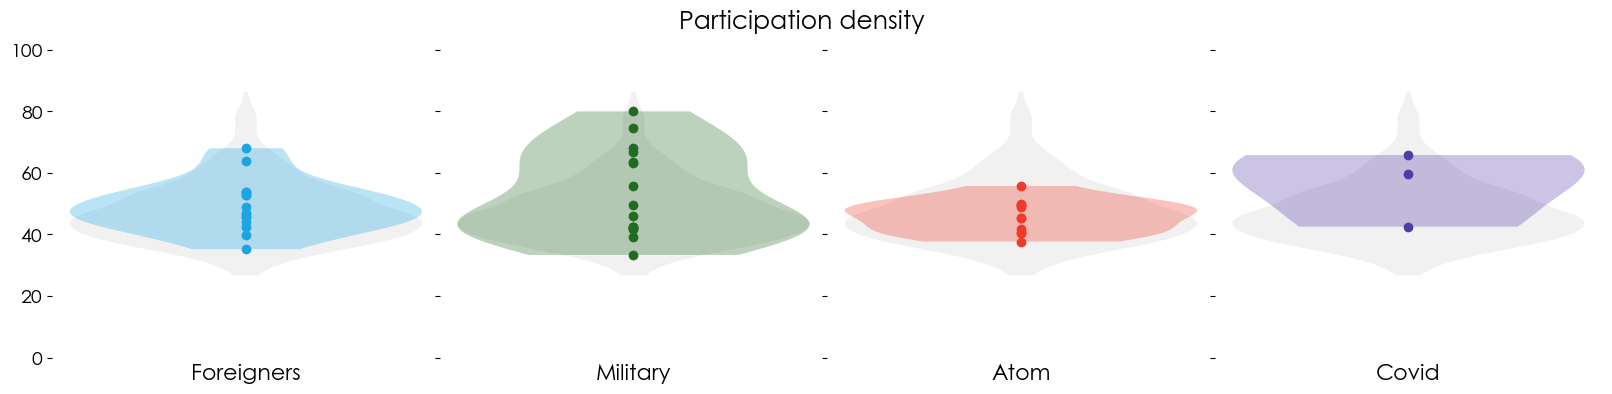

In [45]:
from matplotlib import rcParams
rcParams['font.family'] = 'Century Gothic'
rcParams['font.size'] = 14  

military = military.dropna() # suppress the years before 1880 with missing information
f, ax = plt.subplots(figsize=(20,4), ncols=4, nrows=1, sharex='all', sharey='all')
f.suptitle('Participation density',fontsize=18, fontname='Century Gothic')
f.subplots_adjust(wspace=0)
i = 0
for topic in topics_list:
    ax[i].grid(False)
#    ax[i].grid(axis="x", color="black", linestyle="-", linewidth=0.2)

    ax[i].set_frame_on(False)
    ax[i].set_ylim(bottom=0, top=100)
    ax[i].get_xaxis().set_visible(False)

    # Default violin all data
    part1 = ax[i].violinplot(participation_to_plot.dropna().Beteiligung, showmeans=False, showmedians=False,
                             showextrema=False)
    for pc in part1['bodies']:
        pc.set_facecolor('lightgrey')

    # Violin Plot
    part2 = ax[i].violinplot(topic.Beteiligung, showmeans=False, showmedians=False, showextrema=False)
    for pc in part2['bodies']:
        pc.set_facecolor(graph_colors[i])

    # Scatter
    x_value = [1 for x in range(len(topic.Beteiligung))]
    ax[i].scatter(x_value, topic.Beteiligung, color=graph_colors[i])

    ax[i].set_title(topics_titles[i], y=-0.1, fontsize=16, fontname='Century Gothic')
    
    i += 1

In [46]:
results_ja = votations_results.loc[(votations_results.Kanton == 'Schweiz') & (votations_results.Ergebnis == 'Ja in %')]
results_ja = convert_column_numeric(results_ja, 'DATA', 'Jahr', 'Monat', 'Tag')
results_ja['difference'] = results_ja.DATA -50

foreigners_results_ja = results_ja.loc[results_ja.Vorlage.str.contains('Ausländ')]
atom_results_ja = results_ja.loc[results_ja.Vorlage.str.contains('Atom')]
military_results_ja = results_ja.loc[results_ja.Vorlage.str.contains('Militär')]
covid_results_ja = results_ja.loc[results_ja.Vorlage.str.contains('Covid')]

C:\Users\flora\AppData\Local\Temp\ipykernel_11872\39196558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[name] = pd.to_numeric(dataframe[name], errors='coerce')
C:\Users\flora\AppData\Local\Temp\ipykernel_11872\1486254865.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_ja['difference'] = results_ja.DATA -50


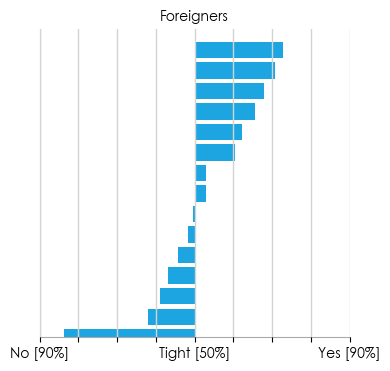

In [53]:
rcParams['font.family'] = 'Century Gothic'
topics_list_ja = [foreigners_results_ja, atom_results_ja, military_results_ja, covid_results_ja]
data = topics_list_ja[0].sort_values("difference", ascending=True)

f, ax = plt.subplots(figsize=(4,4))
ax.set_title(topics_titles[0], loc='Center', y=1, fontsize=10, fontname='Century Gothic')
bars = ax.barh(range(len(data)), data.difference, color=graph_colors[0])

# Customize the x-axis
ax.set_xlim(left=-40, right=40)
ax.set_xticks(ticks=np.linspace(-40, 40, 9))  # Change 9 to the number of desired ticks
ax.set_xticklabels(['No [90%]', '', '', '', 'Tight [50%]', '', '', '', 'Yes [90%]'], fontsize=10, fontname='Century Gothic')

# Customize the y-axis
ax.set_ylim(bottom=0, top=len(data))  # Adjust top based on the number of bars
ax.get_yaxis().set_visible(True)  # Make the y-axis visible
ax.yaxis.set_ticks_position('none')  # Hide y-axis ticks
ax.set_yticklabels([]) 

# Remove y axis scale
ax.get_yaxis().set_visible(False)
ax.get_xaxis().set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_color('darkgrey')
ax.spines['left'].set_color('darkgrey')
ax.grid(axis="x", color="lightgrey", linestyle="-", linewidth=1, zorder=0)
ax.set_axisbelow(True)
# Let frame
ax.set_frame_on(True)
#ax.grid(axis="x", color="white", linestyle="-", linewidth=1, zorder=0)

#Grid in foreground
ax.set_axisbelow(False)

In [18]:
# TODO Montrer l'année de chaque votation? bof?
# TODO Fonction pour exporter le graphe
# TODO Fonction pour exporter le graphe sans sorted?
# TODO Faire un graphe avec la timeline d'un seul thème, comme le scatter plot? Liant les thèmes?